# Iterated Convolution and the Central Limit Effect

Repeated convolution of independent increments drives distributions toward Gaussian profiles under normalization.
This is the probabilistic heart of the central limit theorem (CLT).

Let $X_i$ be i.i.d. with distribution $h$. For partial sums
$$
S_n = X_1+\cdots+X_n,
$$
the law is $h^{(*n)}$. After centering/scaling by $\sqrt n$, histograms approach a bell shape.


## Environment

We represent probability masses on integer grids and convolve iteratively.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

plt.rcParams["figure.dpi"] = 120


## Increment law

A Bernoulli-like two-point law with strong asymmetry.


In [2]:
h = np.array([1.0, 29.0])
h = h / h.sum()
support_h = np.array([0, 1], dtype=float)


## Iterated convolution engine

Compute distributions of sums $S_n$ exactly on a discrete grid.


In [3]:
def iterated_convolutions(h, n_max=60):
    x = np.array([1.0])
    hist = []
    for n in range(1, n_max + 1):
        a = (n - 1)
        supp = np.arange(0, a + 1)
        m = np.sum(supp * x)
        u = (supp - m) / np.sqrt(n)
        hist.append((u.copy(), x.copy()))
        x = np.convolve(x, h)
    return hist

hist = iterated_convolutions(h, n_max=60)


## Interactive CLT visualization

Bars display centered-normalized distributions for increasing convolution depth.


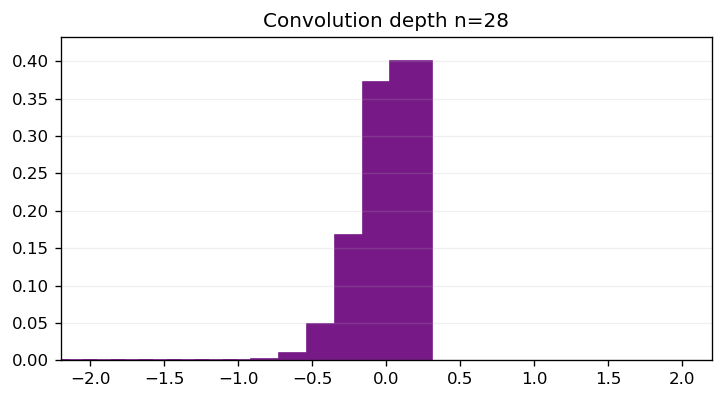

In [4]:
def show_conv(n=1):
    u, x = hist[n - 1]
    col = (n / len(hist), 0.1, 1 - n / len(hist))
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(u, x, width=max(0.03, 1.5 / np.sqrt(n)), color=col, edgecolor=col)
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(0, max(0.2, x.max() * 1.08))
    ax.set_title(f"Convolution depth n={n}")
    ax.grid(alpha=0.2, axis="y")
    plt.show()

# Static call for headless execution (keeps a representative convolution-depth histogram).
show_conv(n=min(28, len(hist)));


## Gaussian overlay

Compare late-stage histogram with a standard Gaussian density.


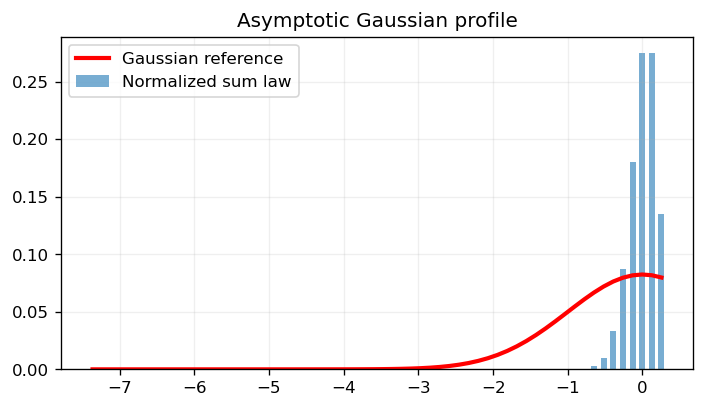

In [5]:
u, x = hist[-1]
g = np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)
g = g / np.sum(g) * np.sum(x)

fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.bar(u, x, width=0.08, alpha=0.6, label="Normalized sum law")
ax.plot(u, g, "r-", lw=2.5, label="Gaussian reference")
ax.set_title("Asymptotic Gaussian profile")
ax.legend()
ax.grid(alpha=0.2)
plt.show()


## Bibliographical resources

- William Feller, *An Introduction to Probability Theory and Its Applications*, Vol. 2.
- Patrick Billingsley, *Probability and Measure*.
- Durrett, *Probability: Theory and Examples*.
